In [1]:
# =========================================================
# 1. IMPORT LIBRARY TENSORFLOW / KERAS
# =========================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import seaborn as sns
import joblib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Cek apakah GPU terdeteksi
print(f"TensorFlow Version: {tf.__version__}")
print("GPU Available: ", len(tf.config.list_physical_devices('GPU')) > 0)

2026-02-15 11:16:27.902333: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771154188.216418      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771154188.306846      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771154189.134239      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771154189.134307      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771154189.134310      24 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Available:  True


In [2]:
# ==============================================================================
# 1. KONFIGURASI
# ==============================================================================
PATH_FILE = '/kaggle/input/open-meteo-data-kebumen/open_meteo_climate/jerukagung_75tahun_lengkap.csv'

In [3]:
# ==============================================================================
# 2. LOAD DATA & BERSIHKAN WAKTU
# ==============================================================================
def load_data(filepath):
    print(f"📂 Membaca file: {filepath}")
    if not os.path.exists(filepath):
        print("❌ File tidak ditemukan.")
        return None
    
    # Baca CSV
    df = pd.read_csv(filepath, index_col='date', parse_dates=True)
    
    # Perbaikan Zona Waktu (Agar tidak geser)
    # 1. Baca sebagai UTC
    df.index = pd.to_datetime(df.index, utc=True)
    # 2. Geser ke WIB
    df.index = df.index.tz_convert('Asia/Jakarta')
    # 3. Hapus label zona waktu (biar jadi jam dinding polos)
    df.index = df.index.tz_localize(None)
    
    df = df.sort_index()
    print(f"✅ Data Siap! Rentang: {df.index.min()} s.d {df.index.max()}")
    return df

df = load_data(PATH_FILE)

df.tail(10)

📂 Membaca file: /kaggle/input/open-meteo-data-kebumen/open_meteo_climate/jerukagung_75tahun_lengkap.csv
✅ Data Siap! Rentang: 1950-01-01 01:00:00 s.d 2026-02-10 23:00:00


,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2026-02-10 14:00:00,29.65,71.507730,23.95,0.1,13.298089,219.50764,1006.83980,3600.0000,100.0,51.0
2026-02-10 15:00:00,28.75,76.464870,24.20,0.1,14.009968,222.91743,1006.73380,3600.0000,100.0,51.0
2026-02-10 16:00:00,28.50,76.426765,23.95,0.0,12.007498,229.86458,1006.53230,3600.0000,100.0,3.0
2026-02-10 17:00:00,27.95,74.745130,23.05,0.1,11.272657,250.40762,1007.12690,1568.7799,100.0,51.0
2026-02-10 18:00:00,25.05,93.348060,23.90,1.7,7.638875,304.43906,1008.70264,0.0000,100.0,61.0
2026-02-10 19:00:00,25.95,91.457054,24.45,1.1,8.694204,332.90454,1009.00824,0.0000,100.0,55.0
2026-02-10 20:00:00,25.45,93.087800,24.25,0.0,7.100310,329.53452,1009.90280,0.0000,100.0,3.0
2026-02-10 21:00:00,25.45,93.367210,24.30,0.2,5.720489,282.72437,1010.40170,0.0000,100.0,51.0
2026-02-10 22:00:00,25.05,94.760220,24.15,0.1,5.743100,302.19570,1010.59845,0.0000,100.0,51.0


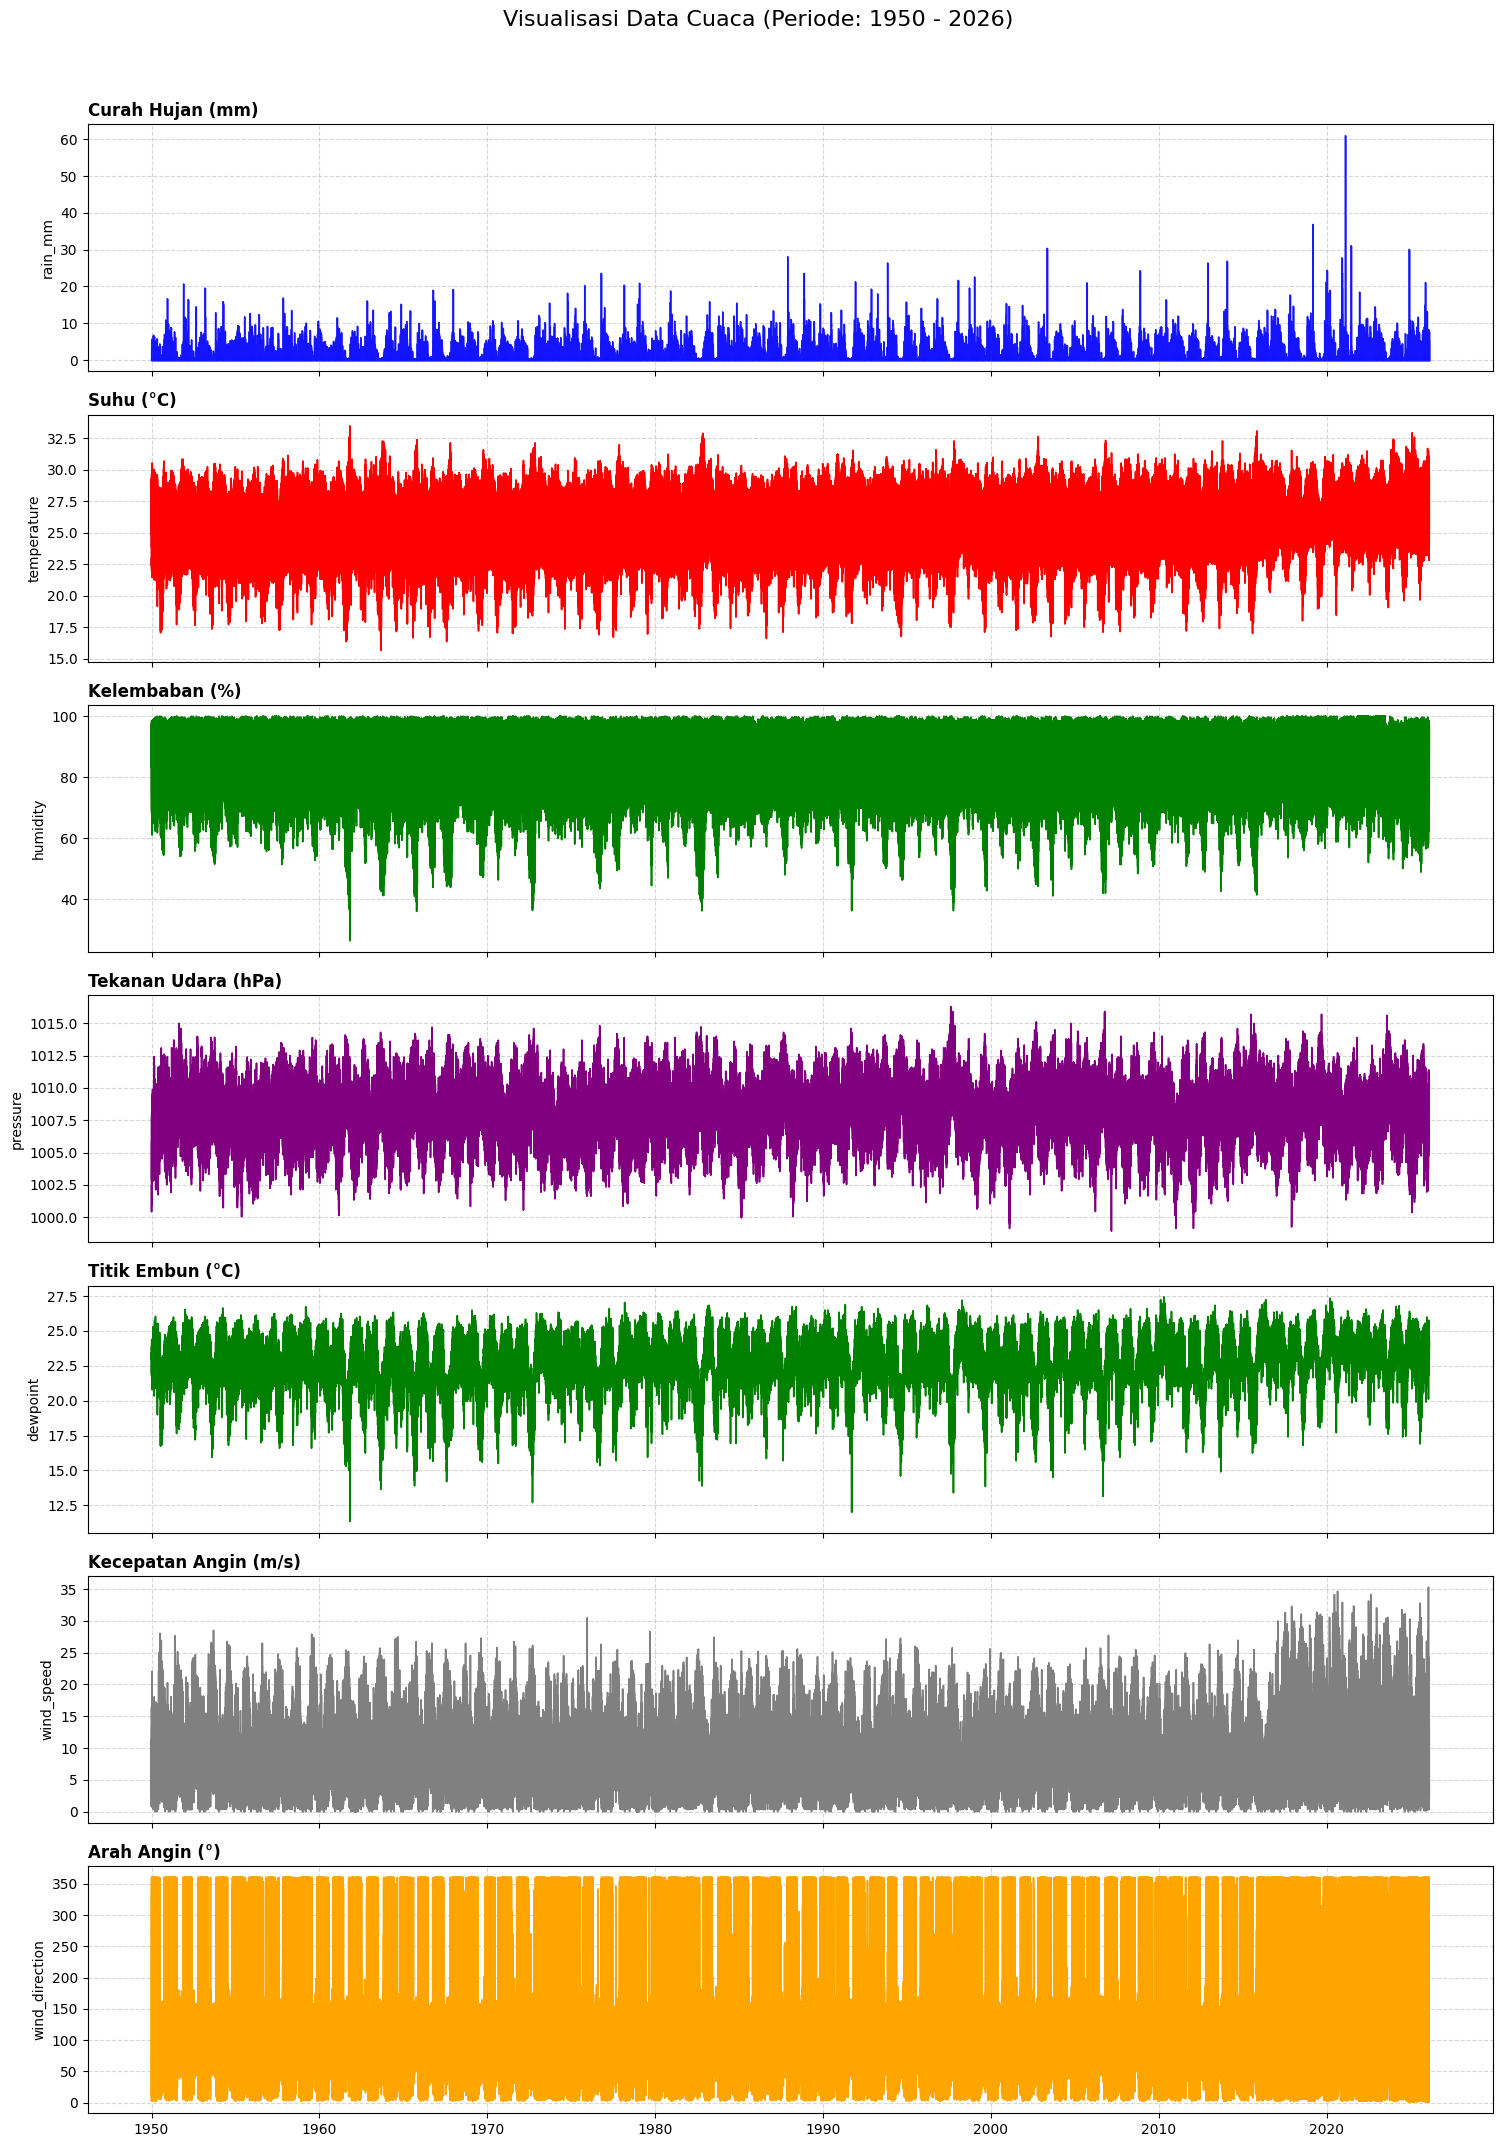

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================
# VISUALISASI TIME SERIES SEMUA VARIABEL
# =========================================================

# 1. Pilih Kolom yang Mau Di-plot (Otomatis deteksi yang ada)
target_cols = ['rain_mm', 'temperature', 'humidity', 'pressure','dewpoint', 'wind_speed', 'wind_direction']
cols_to_plot = [col for col in target_cols if col in df.columns]

# 2. Atur Ukuran Gambar (Tinggi menyesuaikan jumlah kolom)
n_cols = len(cols_to_plot)
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(15, 3 * n_cols), sharex=True)

# 3. Definisikan Warna & Style biar Cantik
colors = {
    'rain_mm': 'blue',
    'temperature': 'red',
    'humidity': 'green',
    'pressure': 'purple',
    'dewpoint': 'green',
    'wind_speed': 'grey',
    'wind_direction': 'orange'
}

titles = {
    'rain_mm': 'Curah Hujan (mm)',
    'temperature': 'Suhu (°C)',
    'humidity': 'Kelembaban (%)',
    'pressure': 'Tekanan Udara (hPa)',
    'dewpoint' : 'Titik Embun (°C)',
    'wind_speed': 'Kecepatan Angin (m/s)',
    'wind_direction': 'Arah Angin (°)'
}

# 4. Loop untuk Menggambar Setiap Variabel
for i, col in enumerate(cols_to_plot):
    ax = axes[i] if n_cols > 1 else axes # Handle jika cuma 1 kolom
    
    # Ambil data (Bisa di-slice kalau terlalu berat, misal: df.tail(1000))
    data = df[col] 
    
    # Khusus Hujan pakai Area Plot (Biar kelihatan volume-nya)
    if col == 'rain_mm':
        ax.fill_between(data.index, data, color=colors.get(col, 'blue'), alpha=0.6)
        ax.plot(data.index, data, color=colors.get(col, 'blue'), alpha=0.8, linewidth=1)
    else:
        # Yang lain pakai Garis biasa
        ax.plot(data.index, data, color=colors.get(col, 'black'), linewidth=1.2)
    
    # Kosmetik Grafik
    ax.set_title(titles.get(col, col), fontsize=12, loc='left', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel(col)

# Judul Besar
plt.suptitle(f'Visualisasi Data Cuaca (Periode: {df.index.min().year} - {df.index.max().year})', 
             y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

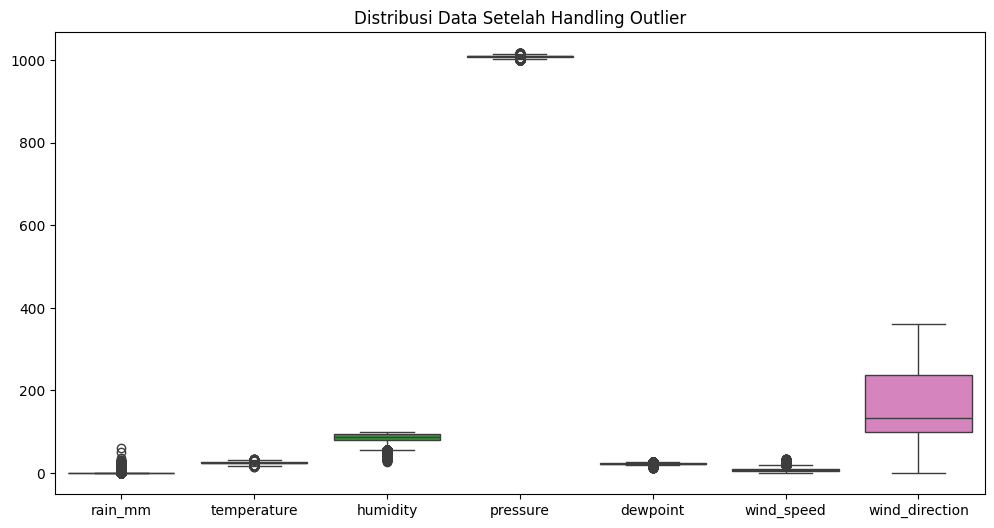

In [5]:
# Gambar Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['rain_mm', 'temperature', 'humidity', 'pressure','dewpoint', 'wind_speed', 'wind_direction']])
plt.title("Distribusi Data Setelah Handling Outlier")
plt.show()

In [6]:
# Ambil data 10 tahun terakhir agar relevan dan training tidak terlalu lama
# (Silakan ubah tahunnya jika mau lebih banyak data)
df_ai = df.loc['2000':'2025'].copy()

In [7]:
df_ai.tail(10)

,temperature,humidity,dewpoint,rain_mm,wind_speed,wind_direction,pressure,sunshine_duration,cloud_cover,weather_code
date,,,,,,,,,,
2025-12-31 14:00:00,28.20,79.185100,24.25,5.3,4.965521,226.468730,1003.83580,0.0,100.0,63.0
2025-12-31 15:00:00,27.10,85.206960,24.40,0.4,5.223103,178.025120,1003.42880,0.0,100.0,51.0
2025-12-31 16:00:00,26.90,86.472466,24.45,0.5,4.680000,112.619910,1003.42725,0.0,100.0,53.0
2025-12-31 17:00:00,26.80,88.029434,24.65,0.1,3.107282,100.007920,1003.72600,0.0,100.0,51.0
2025-12-31 18:00:00,26.30,92.852860,25.05,0.0,1.808978,84.289500,1004.42100,0.0,100.0,3.0
2025-12-31 19:00:00,26.50,89.598580,24.65,0.1,1.094897,279.462250,1005.32043,0.0,100.0,51.0
2025-12-31 20:00:00,26.00,91.734110,24.55,0.0,1.297998,56.309914,1005.81586,0.0,99.0,3.0
2025-12-31 21:00:00,25.75,93.102684,24.55,0.0,0.254558,44.999897,1006.31287,0.0,100.0,3.0
2025-12-31 22:00:00,25.75,94.222496,24.75,0.0,2.448265,323.972530,1006.81177,0.0,100.0,3.0


In [8]:
df_ai.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 227928 entries, 2000-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   temperature        227928 non-null  float64
 1   humidity           227928 non-null  float64
 2   dewpoint           227928 non-null  float64
 3   rain_mm            227928 non-null  float64
 4   wind_speed         227928 non-null  float64
 5   wind_direction     227928 non-null  float64
 6   pressure           227928 non-null  float64
 7   sunshine_duration  227928 non-null  float64
 8   cloud_cover        227928 non-null  float64
 9   weather_code       227928 non-null  float64
dtypes: float64(10)
memory usage: 19.1 MB


🌊 Sedang memproses Kalman Filter...
✅ Data berhasil difilter (Smooth & Denoised).


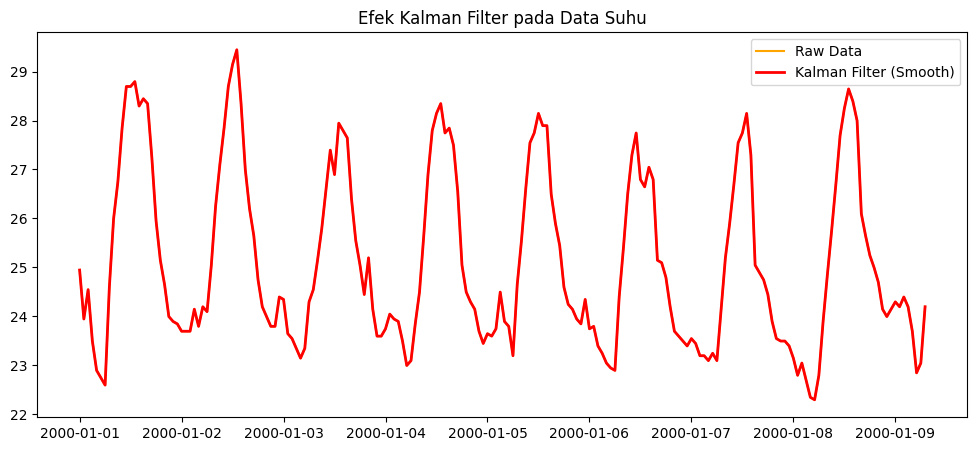

In [9]:
import numpy as np
import pandas as pd

# =========================================================
# FUNGSI PEMANTU: KALMAN FILTER & SPIKE REMOVER
# =========================================================

def kalman_filter(series, process_noise=1e-5, sensor_noise=1e-3):
    """
    Implementasi Kalman Filter 1 Dimensi Sederhana untuk Time Series
    Cocok untuk: Suhu, Kelembapan, Tekanan
    """
    # Inisialisasi
    n_iter = len(series)
    sz = (n_iter,) # size
    
    # Alokasi array
    xhat = np.zeros(sz)      # a posteriori estimate of x
    P = np.zeros(sz)         # a posteriori error estimate
    xhatminus = np.zeros(sz) # a priori estimate of x
    Pminus = np.zeros(sz)    # a priori error estimate
    K = np.zeros(sz)         # gain or blending factor

    # Tebakan awal
    xhat[0] = series.iloc[0]
    P[0] = 1.0

    # Tuning Parameter (Bisa diatur sensivitasnya)
    Q = process_noise # Seberapa cepat sistem berubah (Kecil = Smooth, Besar = Reaktif)
    R = sensor_noise  # Seberapa berisik sensornya (Besar = Lebih smooth)

    for k in range(1, n_iter):
        # 1. Time Update (Prediksi)
        xhatminus[k] = xhat[k-1]
        Pminus[k] = P[k-1] + Q

        # 2. Measurement Update (Koreksi)
        K[k] = Pminus[k] / (Pminus[k] + R)
        xhat[k] = xhatminus[k] + K[k] * (series.iloc[k] - xhatminus[k])
        P[k] = (1 - K[k]) * Pminus[k]

    return pd.Series(xhat, index=series.index)

def hampel_filter(series, window=5, threshold_sigma=3):
    """
    Hampel Filter / Rolling Median untuk Hujan.
    Hanya membuang 'Jarum' (Spike) tanpa merusak pola hujan badai asli.
    """
    # Hitung Median berjalan
    rolling_median = series.rolling(window=window, center=True).median()
    # Hitung Standar Deviasi berjalan (MAD - Median Absolute Deviation lebih robust)
    rolling_std = series.rolling(window=window, center=True).std()
    
    # Deteksi Outlier: Jika nilai jauh dari median sekitarnya
    difference = np.abs(series - rolling_median)
    outlier_idx = difference > (threshold_sigma * rolling_std)
    
    # Ganti outlier dengan nilai mediannya (bukan di-nol-kan, tapi disesuaikan)
    series_clean = series.copy()
    series_clean[outlier_idx] = rolling_median[outlier_idx]
    
    return series_clean.fillna(0) # Handle NaN akibat rolling

# =========================================================
# EKSEKUSI FILTERING
# =========================================================
df_filtered = df_ai.copy()

print("🌊 Sedang memproses Kalman Filter...")

# 1. TEMPERATURE (Kalman)
# Q=1e-5 (Proses lambat), R=0.1 (Sensor agak noise)
df_filtered['temperature'] = kalman_filter(df_filtered['temperature'], process_noise=1e-5, sensor_noise=0.1)

# 2. HUMIDITY (Kalman)
df_filtered['humidity'] = kalman_filter(df_filtered['humidity'], process_noise=1e-5, sensor_noise=0.5)

# 3. PRESSURE (Kalman)
# Tekanan berubah sangat pelan, jadi process_noise kita kecilin banget
df_filtered['pressure'] = kalman_filter(df_filtered['pressure'], process_noise=1e-6, sensor_noise=0.1)

# 4. RAIN (Spike Removal + Physical Cap)
# Hujan JANGAN dikalman. Kita buang spike.
# Langkah A: Buang spike glitch (misal 1 menit 200mm)
df_filtered['rain_mm'] = hampel_filter(df_filtered['rain_mm'], window=3, threshold_sigma=3)

# Langkah B: Physical Cap (Tetap perlu untuk safety, misal max 50mm/jam)
# Angka ini jauh lebih aman daripada hard clip 30mm
df_filtered['rain_mm'] = df_filtered['rain_mm'].clip(lower=0, upper=50)
df_filtered = df_ai

print("✅ Data berhasil difilter (Smooth & Denoised).")

# Cek bedanya
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(df_ai['temperature'].iloc[:200], label='Raw Data', color='orange')
plt.plot(df_filtered['temperature'].iloc[:200], label='Kalman Filter (Smooth)', color='red', linewidth=2)
plt.title("Efek Kalman Filter pada Data Suhu")
plt.legend()
plt.show()

/tmp/ipykernel_24/4036533165.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Fitur', data=importances, palette='viridis', ax=axes[1])


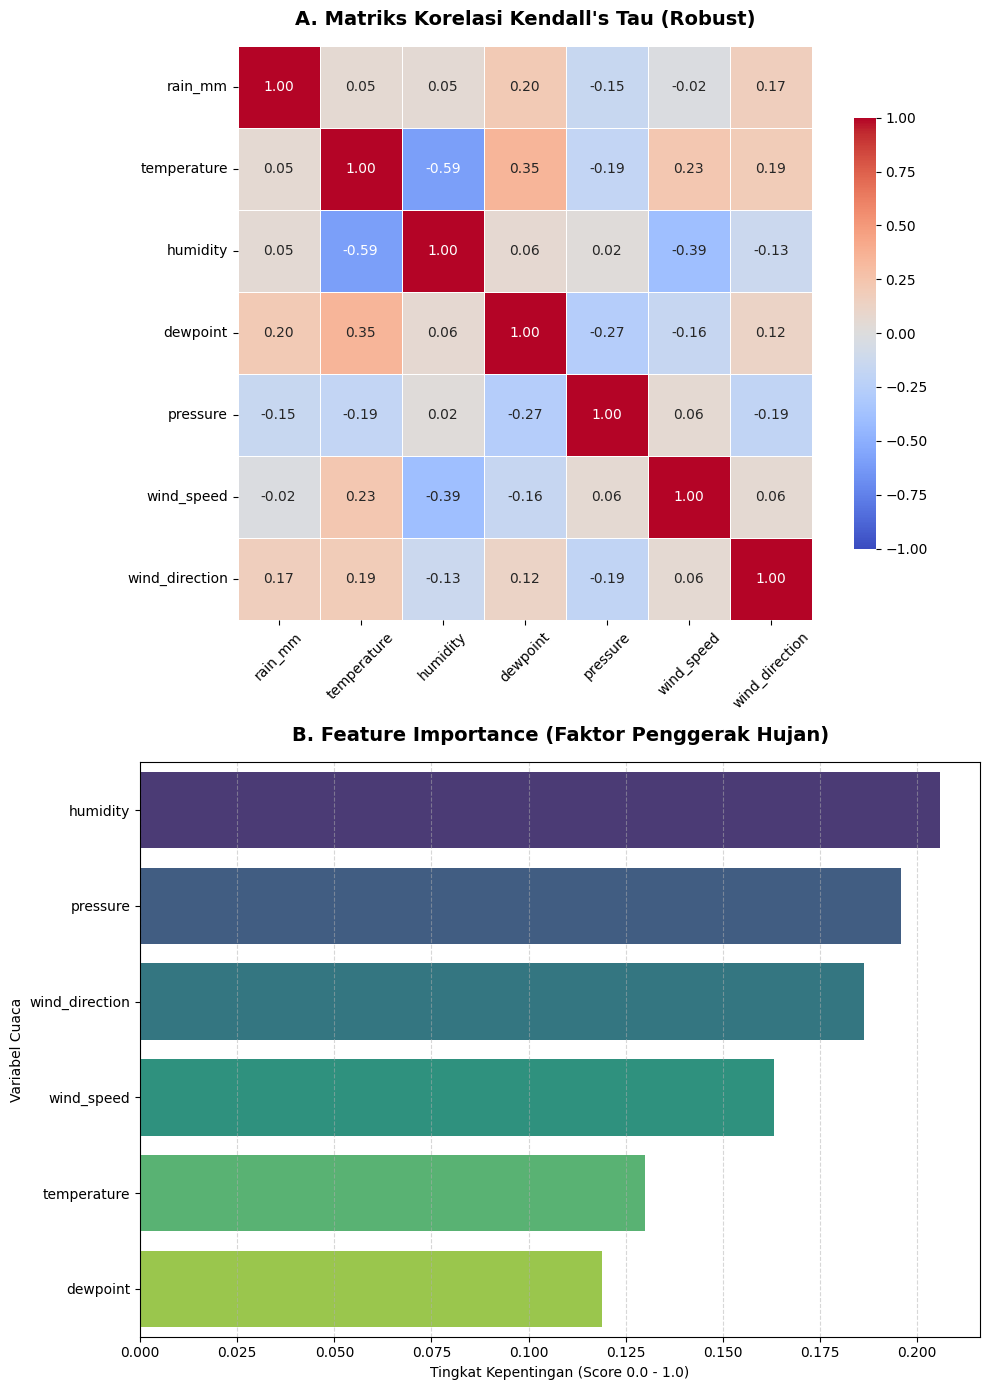

✅ Analisis Selesai!

Top 3 Faktor Paling Berpengaruh terhadap Hujan:
2. humidity (Score: 0.2060)
4. pressure (Score: 0.1959)
6. wind_direction (Score: 0.1863)


In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# ==============================================================================
# 1. PERSIAPAN DATA
# ==============================================================================
# Pastikan data bersih
df_clean = df_ai.copy().dropna()

# List fitur
target = 'rain_mm'
# Hapus variabel yang tidak ada di dataframe kamu biar gak error
candidates = [target, 'temperature', 'humidity', 'dewpoint', 'pressure', 'wind_speed', 'wind_direction','volt']
cols_to_plot = [col for col in candidates if col in df_clean.columns]

# Buat Canvas Besar (2 Baris: Atas Heatmap, Bawah Feature Importance)
fig, axes = plt.subplots(2, 1, figsize=(10, 14))

# ==============================================================================
# 2. PLOT A: HEATMAP KORELASI (KENDALL'S TAU)
# ==============================================================================
# Kita pakai 'kendall' karena lebih robust terhadap data hujan yang zero-inflated
corr_matrix = df_clean[cols_to_plot].corr(method='kendall')

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',  # Merah (+) vs Biru (-) lebih mudah dibaca daripada Viridis
            center=0,         # Titik tengah warna di angka 0
            vmin=-1, vmax=1,  # Kunci skala -1 sampai 1
            linewidths=0.5, 
            square=True,
            cbar_kws={"shrink": 0.75},
            ax=axes[0])       # Taruh di gambar atas

axes[0].set_title("A. Matriks Korelasi Kendall's Tau (Robust)", fontsize=14, fontweight='bold', pad=15)
axes[0].tick_params(axis='x', rotation=45)

# ==============================================================================
# 3. PLOT B: FEATURE IMPORTANCE (RANDOM FOREST)
# ==============================================================================
# Pisahkan X (Fitur) dan y (Target Hujan)
X = df_clean[cols_to_plot].drop(columns=[target])
y = df_clean[target]

# Latih Model Random Forest Sebentar (Hanya untuk intip fitur penting)
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X, y)

# Ambil skor importance
importances = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot Bar Chart
sns.barplot(x='Importance', y='Fitur', data=importances, palette='viridis', ax=axes[1])

axes[1].set_title("B. Feature Importance (Faktor Penggerak Hujan)", fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel("Tingkat Kepentingan (Score 0.0 - 1.0)")
axes[1].set_ylabel("Variabel Cuaca")
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

# ==============================================================================
# 4. FINISHING
# ==============================================================================
plt.tight_layout()

# Simpan gambar HD
plt.savefig('analisis_fitur_lengkap.png', dpi=300, bbox_inches='tight') 
plt.show()

# Print text hasil biar bisa dicopas ke naskah
print("✅ Analisis Selesai!")
print("\nTop 3 Faktor Paling Berpengaruh terhadap Hujan:")
for i, row in importances.head(3).iterrows():
    print(f"{i+1}. {row['Fitur']} (Score: {row['Importance']:.4f})")

In [11]:
# =========================================================
# 2. DATA PREPROCESSING (DENGAN FITUR SIKLUS WAKTU)
# =========================================================
import numpy as np
import pandas as pd # Butuh pandas buat akses index jam/bulan
from sklearn.preprocessing import MinMaxScaler

# 1. SIAPKAN DATAFRAME & FITUR WAKTU
# Pastikan data urut waktu
df_lstm = df_ai.sort_index().copy()

# --- [BARU] REKAYASA FITUR SIKLUS (TIME CYCLES) ---
# Kita ubah Jam (0-23) dan Bulan (1-12) jadi Gelombang Sinus/Cosinus
# Agar LSTM tau bahwa Jam 23.00 itu dekat dengan Jam 00.00
df_lstm['hour_sin'] = np.sin(2 * np.pi * df_lstm.index.hour / 24)
df_lstm['hour_cos'] = np.cos(2 * np.pi * df_lstm.index.hour / 24)
df_lstm['month_sin'] = np.sin(2 * np.pi * df_lstm.index.month / 12)
df_lstm['month_cos'] = np.cos(2 * np.pi * df_lstm.index.month / 12)

# A. Pilih Fitur (Update dengan Fitur Baru)
# Urutan: Fisika -> Waktu -> Target
fitur_input = [
    'temperature', 'humidity','dewpoint', 'pressure', 'wind_speed', 'wind_direction', # Fisika Dasar
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos',    # Waktu (Baru)
    'rain_mm'                                            # Target
]
target_col = 'rain_mm'

# Ambil nilai hanya kolom yang dipilih
data_values = df_lstm[fitur_input].values 

# B. Scaling (Sama seperti sebelumnya)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data_values)

# --- PENTING: CARI INDEX TARGET YANG BENAR ---
target_idx = fitur_input.index(target_col) 
print(f"✅ Target '{target_col}' ditemukan di index ke-{target_idx} dari list fitur.")

# C. Fungsi Sequence (Sama seperti sebelumnya)
def create_sequences(data, seq_length=24):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:(i + seq_length)]) 
        y.append(data[i + seq_length, target_idx]) 
    return np.array(X), np.array(y)

# D. Eksekusi
SEQ_LENGTH = 24
X, y = create_sequences(scaled_data, SEQ_LENGTH)

# E. Split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print("-" * 30)
print(f"Shape X_train: {X_train.shape}")
print(f"Fitur Input  : {len(fitur_input)} variabel")
print(f"Variabel     : {fitur_input}")

✅ Target 'rain_mm' ditemukan di index ke-10 dari list fitur.
------------------------------
Shape X_train: (182323, 24, 11)
Fitur Input  : 11 variabel
Variabel     : ['temperature', 'humidity', 'dewpoint', 'pressure', 'wind_speed', 'wind_direction', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'rain_mm']


In [12]:
model = Sequential()

# Layer 1: LSTM + Dropout
# return_sequences=True wajib karena kita mau oper ke LSTM lagi
model.add(LSTM(units=96, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2)) # Matikan 20% neuron biar gak overfitting

# Layer 2: LSTM + Dropout
# return_sequences=False karena ini langkah terakhir LSTM sebelum masuk Dense
model.add(LSTM(units=64, return_sequences=True))
model.add(Dropout(0.2)) # Matikan 20% neuron lagi
model.add(LSTM(units=64, return_sequences=False))
# Layer 3: Dense (Hidden Layer)
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=16, activation='relu'))

# Layer Output: 1 Neuron (Prediksi Curah Hujan)
# PENTING: Pakai 'relu' agar hasil tidak pernah negatif (Rain >= 0)
model.add(Dense(units=1, activation='linear'))

# Kompilasi Model
# Optimizer Adam dengan learning rate sedikit lebih kecil biar belajar pelan tapi pasti
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, 
              loss='mse',      # MSE bagus untuk menghukum kesalahan besar (badai)
              metrics=['mae']) # MAE enak dibaca manusia (rata-rata meleset berapa mm)

model.summary()

I0000 00:00:1771154316.581474      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 96)         │        41,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 64)         │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,497 (478.50 KB)

 Trainable params: 122,497 (478.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1771154322.395770      83 cuda_dnn.cc:529] Loaded cuDNN version 91002


1425/1425 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - loss: 1.8586e-04 - mae: 0.0061 - val_loss: 2.5189e-04 - val_mae: 0.0054 - learning_rate: 0.0010
Epoch 2/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 1.4281e-04 - mae: 0.0051 - val_loss: 1.7105e-04 - val_mae: 0.0047 - learning_rate: 0.0010
Epoch 3/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 9.1919e-05 - mae: 0.0043 - val_loss: 1.6802e-04 - val_mae: 0.0049 - learning_rate: 0.0010
Epoch 4/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 8.9361e-05 - mae: 0.0041 - val_loss: 1.6760e-04 - val_mae: 0.0051 - learning_rate: 0.0010
Epoch 5/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 8.6127e-05 - mae: 0.0041 - val_loss: 1.6204e-04 - val_mae: 0.0052 - learning_rate: 0.0010
Epoch 6/100
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 8.5478e-05 - mae: 0.0040
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1425/1425 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 8.5478e-05 - mae: 0

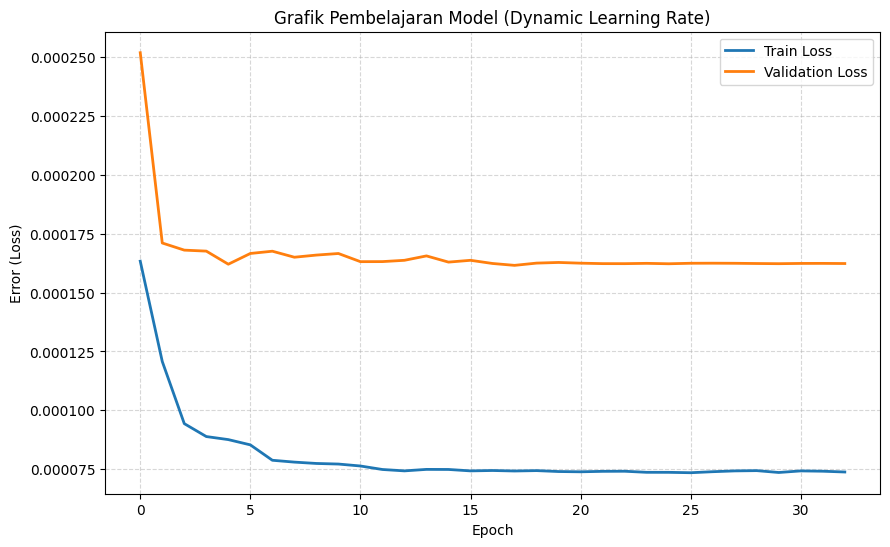

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# =========================================================
# 4. TRAINING MODEL (DENGAN LR SCHEDULER)
# =========================================================

# 1. Callback Stop Otomatis (Satpam)
# Kita naikkan patience ke 15, supaya ReduceLR punya waktu untuk bekerja dulu
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# 2. Callback Turunkan Learning Rate (Solusi Jitu)
# Logika: Jika dalam 5 epoch loss gak turun, perkecil langkah belajar (Learning Rate)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,       # Turunkan LR jadi 20% dari sebelumnya (Diskon besar-besaran)
    patience=5,       # Tunggu 5 epoch, kalau masih mentok baru dieksekusi
    min_lr=1e-6,      # Batas bawah biar gak jadi 0
    verbose=1         # Nanti akan muncul teks: "Reduce LR to..."
)

history = model.fit(
    X_train, y_train,
    epochs=100,       
    batch_size=128,   
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr], # <--- Masukkan reduce_lr di sini!
    verbose=1
)

# Plot Loss History
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Grafik Pembelajaran Model (Dynamic Learning Rate)')
plt.ylabel('Error (Loss)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [14]:
# =========================================================
# 5. PREDIKSI & INVERSE TRANSFORM
# =========================================================

# A. Prediksi (Masih Skala 0-1)
y_pred_scaled = model.predict(X_test)

# B. Kembalikan ke Satuan Asli (mm)
# Kita butuh trik karena scaler awalnya fit dengan banyak kolom,
# sedangkan y_pred cuma 1 kolom. Kita buat dummy array.

def inverse_transform_target(pred_array, scaler_obj, target_col_idx, n_features):
    # Buat array kosong seukuran fitur asli
    dummy = np.zeros((len(pred_array), n_features))
    # Isi kolom target dengan prediksi
    dummy[:, target_col_idx] = pred_array.flatten()
    # Inverse transform
    inverted = scaler_obj.inverse_transform(dummy)
    # Ambil kembali kolom target saja
    return inverted[:, target_col_idx]

# Jumlah fitur total
n_features = X_train.shape[2]

# Inverse Prediksi & Target Asli
y_pred_final = inverse_transform_target(y_pred_scaled, scaler, target_idx, n_features)
y_test_final = inverse_transform_target(y_test.reshape(-1, 1), scaler, target_idx, n_features)

# C. Koreksi Fisika (Tidak boleh negatif)
y_pred_final = np.maximum(y_pred_final, 0)
y_test_final = np.maximum(y_test_final, 0)

print("✅ Prediksi Selesai dan dikonversi ke mm.")
print(f"Contoh Prediksi: {y_pred_final[:5]}")
print(f"Contoh Asli    : {y_test_final[:5]}")

1425/1425 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
✅ Prediksi Selesai dan dikonversi ke mm.
Contoh Prediksi: [0.52091039 0.62571751 0.91270386 0.3620174  0.3641311 ]
Contoh Asli    : [0.7 1.1 0.1 0.1 0.1]


EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)

[1] Ketepatan Angka (Regression Metrics):
   - MAE (Rata-rata Meleset) : 0.280 mm
   - RMSE (Kesalahan Besar)  : 0.775 mm
   - R² (Kecocokan Pola)     : 0.401 (Max 1.0)

[2] Metrik Hidrologi (Scientific):
   - Pearson Corr (r)        : 0.638 (Linear)
   - Spearman Corr (rho)     : 0.598 (Ranking/Monotonik)
   - KGE Score               : 0.541
     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)

[3] Kemampuan Deteksi Hujan (Threshold > 1.0 mm):
   - POD (Probability of Detection): 41.93% (Sensitivitas)
   - FAR (False Alarm Ratio)       : 51.51% (Tingkat 'Prank')
   - CSI (Critical Success Index)  : 29.01% (Akurasi Gabungan)


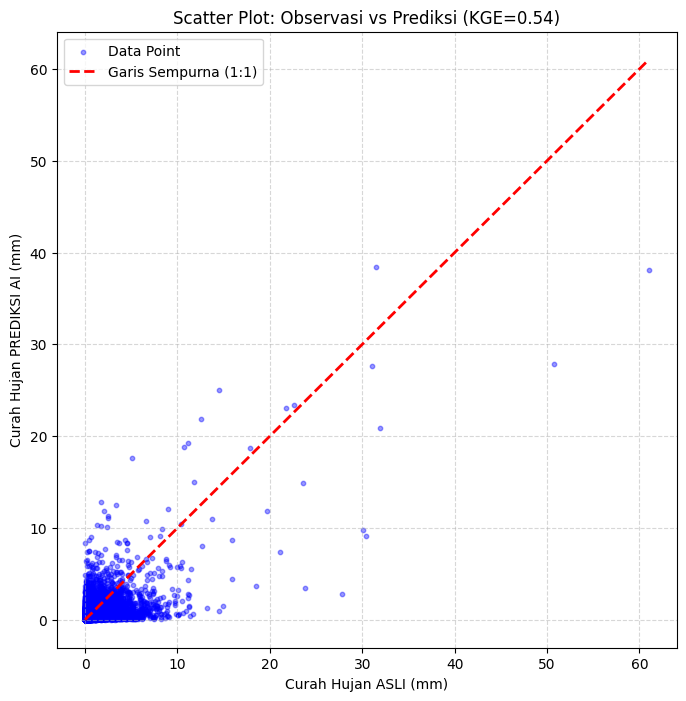

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

def evaluasi_pro(y_true, y_pred, threshold_hujan=1.0):
    # 0. PREPROCESSING: FLATTEN ARRAY (PENTING!)
    # Memastikan input menjadi array 1 dimensi agar tidak error dimensi
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    print("="*60)
    print("EVALUASI PERFORMA MODEL (METEOROLOGI STANDARD)")
    print("="*60)

    # --- 1. METRIK REGRESI (STANDAR) ---
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n[1] Ketepatan Angka (Regression Metrics):")
    print(f"   - MAE (Rata-rata Meleset) : {mae:.3f} mm")
    print(f"   - RMSE (Kesalahan Besar)  : {rmse:.3f} mm")
    print(f"   - R² (Kecocokan Pola)     : {r2:.3f} (Max 1.0)")

    # --- 2. METRIK HIDROLOGI (KGE & KORELASI) ---
    # Hitung Komponen KGE
    r_pearson = np.corrcoef(y_true, y_pred)[0, 1]
    r_spearman, _ = stats.spearmanr(y_true, y_pred) # Tambahan Spearman
    
    alpha = np.std(y_pred) / np.std(y_true) # Variabilitas
    beta = np.mean(y_pred) / np.mean(y_true) # Bias

    # Rumus KGE Original (Gupta et al., 2009)
    kge = 1 - np.sqrt((r_pearson - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

    print(f"\n[2] Metrik Hidrologi (Scientific):")
    print(f"   - Pearson Corr (r)        : {r_pearson:.3f} (Linear)")
    print(f"   - Spearman Corr (rho)     : {r_spearman:.3f} (Ranking/Monotonik)")
    print(f"   - KGE Score               : {kge:.3f}")
    print(f"     (> 0.5 = Bagus, > 0.7 = Sangat Bagus, 1.0 = Sempurna)")

    # --- 3. METRIK DETEKSI (KLASIFIKASI TURUNAN) ---
    # Threshold hujan (misal > 1.0 mm dianggap hujan)
    y_true_class = (y_true > threshold_hujan).astype(int)
    y_pred_class = (y_pred > threshold_hujan).astype(int)

    print(f"\n[3] Kemampuan Deteksi Hujan (Threshold > {threshold_hujan} mm):")
    
    # Cek apakah ada kejadian hujan di data test
    if np.sum(y_true_class) == 0:
        print("   ⚠️ Peringatan: Tidak ada kejadian hujan di data test ini.")
    else:
        # Confusion Matrix
        # ravel() meratakan array jadi: True Negative, False Positive, False Negative, True Positive
        try:
            tn, fp, fn, tp = confusion_matrix(y_true_class, y_pred_class).ravel()
            
            # Tambah epsilon (1e-10) biar gak error division by zero
            pod = tp / (tp + fn + 1e-10) # Probability of Detection
            far = fp / (fp + tp + 1e-10) # False Alarm Ratio
            csi = tp / (tp + fn + fp + 1e-10) # Critical Success Index

            print(f"   - POD (Probability of Detection): {pod:.2%} (Sensitivitas)")
            print(f"   - FAR (False Alarm Ratio)       : {far:.2%} (Tingkat 'Prank')")
            print(f"   - CSI (Critical Success Index)  : {csi:.2%} (Akurasi Gabungan)")
        except ValueError:
            print("   ⚠️ Gagal menghitung confusion matrix (Mungkin data hanya berisi 1 kelas).")

    # --- 4. VISUALISASI SCATTER PLOT ---
    plt.figure(figsize=(8, 8))
    
    # Scatter plot
    plt.scatter(y_true, y_pred, alpha=0.4, color='blue', s=10, label='Data Point')

    # Garis Identitas (Target Sempurna 1:1)
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Garis Sempurna (1:1)')

    plt.title(f"Scatter Plot: Observasi vs Prediksi (KGE={kge:.2f})")
    plt.xlabel("Curah Hujan ASLI (mm)")
    plt.ylabel("Curah Hujan PREDIKSI AI (mm)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# --- CARA PAKAI ---
evaluasi_pro(y_test_final, y_pred_final)

📊 Menyiapkan Plot Semua Variabel...


/tmp/ipykernel_24/1926443499.py:72: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


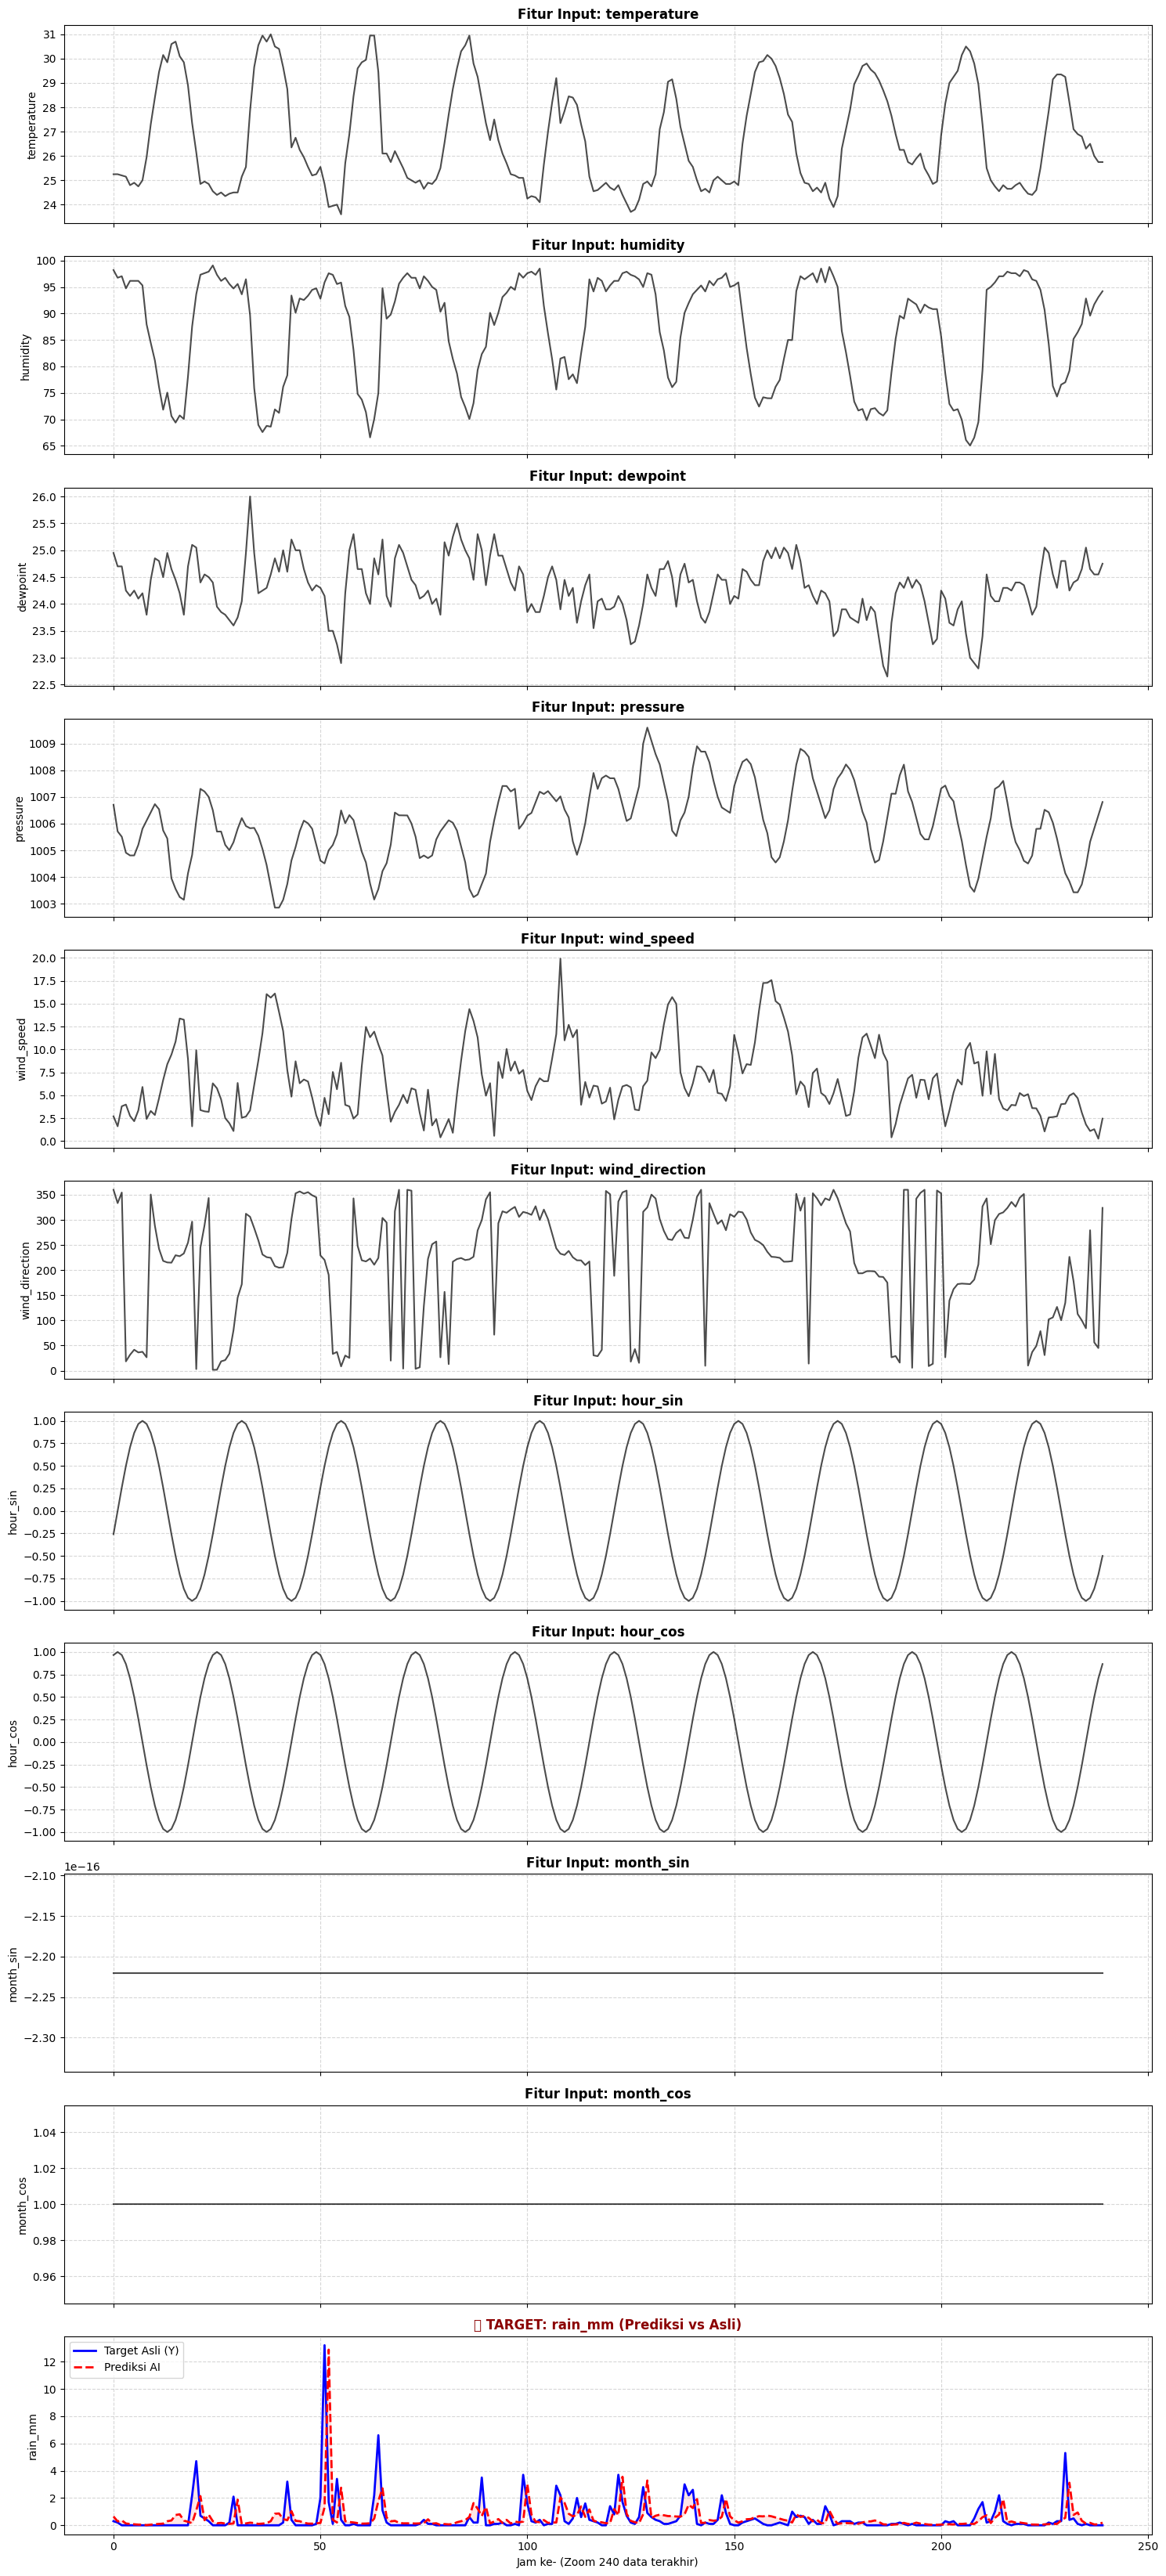

In [16]:
# =========================================================
# 🔍 VISUALISASI SEMUA VARIABEL (SANITY CHECK)
# =========================================================
import matplotlib.pyplot as plt
import numpy as np

print("📊 Menyiapkan Plot Semua Variabel...")

# 1. AMBIL DATA INPUT (X_test) UNTUK DIPLOT
# X_test bentuknya (Sample, 24 Jam, Fitur).
# Kita ambil jam terakhir dari setiap window (indeks -1) sebagai representasi "Saat Ini"
X_test_last_step = X_test[:, -1, :] 

# 2. KEMBALIKAN KE SATUAN ASLI (INVERSE TRANSFORM)
# Karena X_test itu isinya semua fitur yang sudah di-scale 0-1
X_test_real = scaler.inverse_transform(X_test_last_step)

# 3. SIAPKAN DATA PREDIKSI & ASLI (Y)
# Gunakan data yang sudah di-inverse di cell sebelumnya (y_test_final, y_pred_final)
# Kita potong agar panjangnya sama dengan zoom range nanti

# 4. SETTING PLOT
# Ambil nama fitur dari variabel 'fitur_input' yang kamu buat di awal
# Kalau lupa, kita definisikan ulang (Pastikan urutannya SAMA dengan saat training!)
cols_to_plot = fitur_input # Contoh: ['temp', 'humidity', 'pressure', 'wind', 'rain_mm']

n_cols = len(cols_to_plot)
zoom_range = 240  # Lihat
start_idx = -zoom_range

# Buat Canvas Gambar
fig, axes = plt.subplots(nrows=n_cols, ncols=1, figsize=(15, 3 * n_cols), sharex=True)

# 5. LOOPING UNTUK GAMBAR SETIAP VARIABEL
for i, col_name in enumerate(cols_to_plot):
    ax = axes[i] if n_cols > 1 else axes
    
    # Ambil data fitur ke-i untuk 300 jam terakhir
    feature_data = X_test_real[start_idx:, i]
    
    # --- LOGIKA KHUSUS UNTUK TARGET (RAIN_MM) ---
    # Jika kolom ini adalah target, kita plot Asli vs Prediksi
    if col_name == target_col: # target_col = 'rain_mm'
        # Plot Data Asli (Input X) - Opsional, buat cek konsistensi
        # ax.plot(feature_data, color='green', alpha=0.3, label='Input X (History)')
        
        # Plot Target Asli (Y Test)
        ax.plot(y_test_final[start_idx:], color='blue', label='Target Asli (Y)', linewidth=2)
        
        # Plot Prediksi AI
        ax.plot(y_pred_final[start_idx:], color='red', linestyle='--', label='Prediksi AI', linewidth=2)
        
        # Area Error
        ax.fill_between(range(zoom_range), 
                        y_test_final[start_idx:].flatten(), 
                        y_pred_final[start_idx:].flatten(), 
                        color='red', alpha=0.1)
        
        ax.set_title(f"⭐ TARGET: {col_name} (Prediksi vs Asli)", fontweight='bold', color='darkred')
        ax.legend(loc='upper left')
        
    else:
        # --- UNTUK VARIABEL PENDUKUNG (SUHU, TEKANAN, DLL) ---
        ax.plot(feature_data, color='black', alpha=0.7)
        ax.set_title(f"Fitur Input: {col_name}", fontweight='bold')

    # Kosmetik Grafik
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylabel(col_name)

plt.xlabel(f"Jam ke- (Zoom {zoom_range} data terakhir)")
plt.tight_layout()
plt.show()

⏳ Sedang memprediksi dengan LSTM...

📊 HASIL EVALUASI LSTM:
   - MAE : 0.28 mm
   - R2  : 0.4005


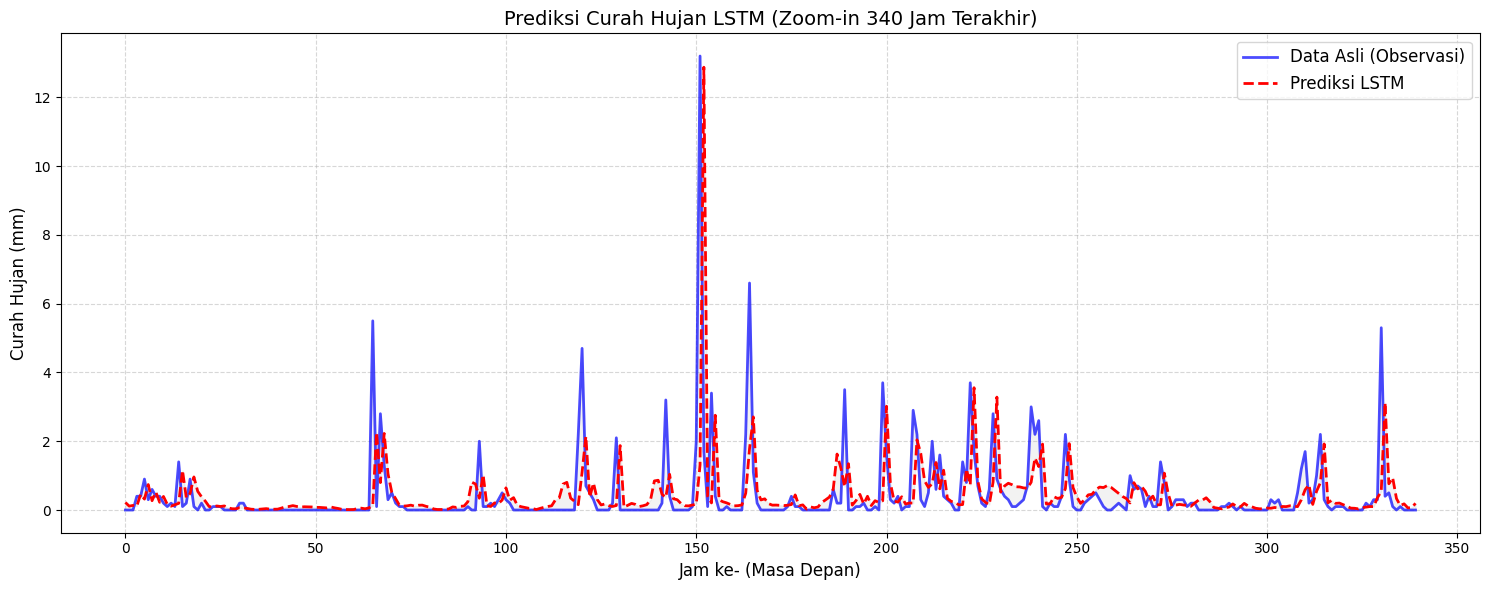

In [17]:
# =========================================================

# VISUALISASI HASIL LSTM (VERSI PERBAIKAN FINAL)

# =========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# --- 1. PREDIKSI (GUNAKAN X_test YANG 3 DIMENSI) ---
print("⏳ Sedang memprediksi dengan LSTM...")
# PERBAIKAN DISINI: Ganti X_test_flat jadi X_test
y_pred_scaled = model.predict(X_test, verbose=0) 
# --- 2. INVERSE TRANSFORM (TRIK DUMMY ARRAY) ---
# Fungsi ini wajib karena Scaler LSTM biasanya memuat banyak kolom (Suhu, Tekanan, dll)
# sedangkan output prediksi cuma 1 kolom (Hujan). Kita harus "menipu" scaler-nya.
def inverse_helper(pred_data, scaler_obj, n_features, target_index):
    # Buat array kosong seukuran (Jumlah Data x Jumlah Fitur)
    dummy = np.zeros((len(pred_data), n_features))
    # Tempelkan hasil prediksi ke posisi kolom target yang benar
    dummy[:, target_index] = pred_data.flatten()
    # Balikkan skalanya (Inverse Transform)
    inverted = scaler_obj.inverse_transform(dummy)
    # Ambil kembali HANYA kolom targetnya
    return inverted[:, target_index]
# Ambil informasi bentuk data dari X_test
# X_test shape: (Jumlah Data, TimeSteps, Jumlah Fitur)
n_features = X_test.shape[2] 
# Pastikan target_idx sudah ada (dari cell preprocessing sebelumnya)
# Jika error "target_idx not defined", uncomment baris di bawah ini dan sesuaikan angkanya:
# target_idx = 4  # Misal hujan ada di urutan ke-4 (0,1,2,3,4)
# Lakukan Inverse Transform
y_pred_final = inverse_helper(y_pred_scaled, scaler, n_features, target_idx)
y_test_final = inverse_helper(y_test.reshape(-1, 1), scaler, n_features, target_idx)
# Koreksi Fisika (Hujan tidak boleh negatif)
y_pred_final = np.maximum(y_pred_final, 0)
y_test_final = np.maximum(y_test_final, 0)

# --- 3. HITUNG SKOR ---
print(f"\n📊 HASIL EVALUASI LSTM:")
mae = mean_absolute_error(y_test_final, y_pred_final)
r2 = r2_score(y_test_final, y_pred_final)
print(f"   - MAE : {mae:.2f} mm")
print(f"   - R2  : {r2:.4f}")

# --- 4. GAMBAR GRAFIK (TIME SERIES PLOT) ---
plt.figure(figsize=(15, 6))
# Zoom in ke 240 jam terakhir (10 hari) biar detail terlihat
zoom_range = 340 
start_idx = -zoom_range
# Plot Data Asli
plt.plot(y_test_final[start_idx:], label='Data Asli (Observasi)', color='blue', linewidth=2, alpha=0.7)
# Plot Prediksi LSTM
plt.plot(y_pred_final[start_idx:], label='Prediksi LSTM', color='red', linestyle='--', linewidth=2)
plt.title(f'Prediksi Curah Hujan LSTM (Zoom-in {zoom_range} Jam Terakhir)', fontsize=14)
plt.ylabel('Curah Hujan (mm)', fontsize=12)
plt.xlabel('Jam ke- (Masa Depan)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Area Fill (Selisih Error)
plt.fill_between(range(zoom_range), 
                 y_test_final[start_idx:].flatten(), 
                 y_pred_final[start_idx:].flatten(), 
                 color='gray', alpha=0.1, label='Selisih Error')
plt.tight_layout()
plt.show()

In [18]:
print("💾 Sedang menyimpan model dan scaler...")

# --- 1. SIMPAN MODEL (Deteksi Tipe Model) ---
try:
    # Cara Simpan Model Deep Learning (LSTM/Keras)
    # Format .h5 atau .keras lebih aman untuk TensorFlow
    model.save('model_hujan_lstm.keras')
    print("   -> ✅ Model LSTM berhasil disimpan sebagai 'model_hujan_lstm.h5'")
except:
    # Cara Simpan Model Machine Learning Biasa (XGBoost/Ensemble)
    joblib.dump(model, 'model_hujan_ensemble.pkl')
    print("   -> ✅ Model Ensemble berhasil disimpan sebagai 'model_hujan_ensemble.pkl'")

# --- 2. SIMPAN SCALER (Deteksi Variabel Scaler) ---
# Cek apakah kita pakai 'scaler' (LSTM) atau 'scaler_X' (Ensemble)

if 'scaler' in globals():
    # Kasus LSTM: Cuma ada 1 scaler untuk semua data
    joblib.dump(scaler, 'scaler_lstm.pkl')
    print("   -> ✅ Scaler (Single) berhasil disimpan sebagai 'scaler_lstm.pkl'")
    
elif 'scaler_X' in globals() and 'scaler_y' in globals():
    # Kasus Ensemble: Ada 2 scaler terpisah
    joblib.dump(scaler_X, 'scaler_X.pkl')
    joblib.dump(scaler_y, 'scaler_y.pkl')
    print("   -> ✅ Scaler X dan y berhasil disimpan.")

else:
    print("   -> ⚠️ PERINGATAN: Variabel scaler tidak ditemukan di memori.")

print("\n🎉 Selesai! File siap didownload.")

💾 Sedang menyimpan model dan scaler...
   -> ✅ Model LSTM berhasil disimpan sebagai 'model_hujan_lstm.h5'
   -> ✅ Scaler (Single) berhasil disimpan sebagai 'scaler_lstm.pkl'

🎉 Selesai! File siap didownload.
